# Route-3 7D Fresh Independent Held-out Validation

This notebook reads the single, frozen primary decision on 1,024 new theta/seed
cases. No configuration, calibrator, threshold, feature, or prior is changed
after opening this final set. Raw and calibrated evidence remain distinct.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "S4_sbi").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "S4_sbi").exists():
    raise RuntimeError("sleep_loop project root could not be resolved")
sys.path.insert(0, str(PROJECT_ROOT / "S4_sbi" / "src"))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "route3_7d_rescue"
print("CONDA_DEFAULT_ENV=", os.environ.get("CONDA_DEFAULT_ENV"))
print("sys.executable=", sys.executable)
print("sys.prefix=", sys.prefix)
print("PROJECT_ROOT=", PROJECT_ROOT)
assert "neurolib" in sys.executable.lower()


CONDA_DEFAULT_ENV= neurolib
sys.executable= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
sys.prefix= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib
PROJECT_ROOT= D:\Year3_Mao_Projects\sleep_loop


## Final dataset and posterior integrity


In [2]:
from sleep_sbi.route3_7d_rescue import FINAL_ROOT
manifest = json.loads((FINAL_ROOT / "dataset" / "manifest.json").read_text())
decision = json.loads((FINAL_ROOT / "ROUTE3_7D_RESCUE_FINAL_DECISION.json").read_text())
display(pd.Series(manifest, name="value").to_frame())
display(pd.Series(decision["checks"], name="value").to_frame())
assert manifest["scheduled"] == 1024
assert manifest["valid"] + manifest["failed"] == 1024


,value
created_utc,2026-07-28T03:40:54.697493+00:00
scheduled,1024
valid,1024
failed,0
failure_rate,0.0
sum_simulator_runtime_s,9174.262442
median_simulator_runtime_s,8.780754
artifact,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...
artifact_sha256,0d48482345dcb3c68d0a13f9ca4624fc625e8caf5cdd12...
simulator_seed_hash,0d48482345dcb3c68d0a13f9ca4624fc625e8caf5cdd12...


,value
preflight_engineering_gate,True
training_failure_gate,True
heldout_failure_gate,True
posterior_finite_support_rate,1.0
posterior_finite_support_gate,True
prior_level_unrecoverable_parameter_count,0
prior_level_unrecoverable_gate,True
systematically_worse_parameter_count,0
systematic_worsening_gate,True
better_than_prior_parameter_count,7


## Parameter recovery, required coverage, and SBC


In [3]:
method = decision["applies_to"]
recovery = pd.read_csv(FINAL_ROOT / "metrics" / "primary" / "parameter_recovery.csv")
coverage = pd.read_csv(FINAL_ROOT / "metrics" / "primary" / "coverage_curve.csv")
sbc = pd.read_csv(FINAL_ROOT / "metrics" / "primary" / "sbc_ranks.csv")
display(recovery.round(5))
display(coverage[(coverage.estimator == method) & coverage.nominal_level.isin([0.5, 0.8, 0.9])].round(5))
display(sbc[sbc.estimator == method].round(5))


,estimator,parameter,prior_median_mae,posterior_median_mae,posterior_median_rmse,posterior_mean_mae,mae_improvement_fraction,rank_correlation,median_90_ci_width,median_80_ci_width,median_50_ci_width,boundary_sample_fraction
0,empirical_rank_calibrated,mue,0.25,0.14517,0.18048,0.14564,0.41934,0.77691,0.56446,0.47944,0.29963,0.01843
1,empirical_rank_calibrated,mui,0.25,0.00345,0.00576,0.00345,0.98621,0.99980,0.01115,0.00838,0.00402,0.01878
2,empirical_rank_calibrated,b,0.25,0.07924,0.10889,0.08014,0.68304,0.92662,0.26761,0.22239,0.11694,0.01219
3,empirical_rank_calibrated,tauA,0.25,0.18363,0.22573,0.18450,0.26550,0.60051,0.73504,0.64175,0.38855,0.02167
4,empirical_rank_calibrated,g_LK,0.25,0.14305,0.19914,0.14515,0.42782,0.71721,0.50649,0.41751,0.25447,0.01946
5,empirical_rank_calibrated,g_h,0.25,0.12143,0.16865,0.12380,0.51429,0.81397,0.47185,0.38991,0.19357,0.01766
6,empirical_rank_calibrated,c_th2ctx,0.25,0.14009,0.18790,0.14591,0.43965,0.76348,0.60500,0.49232,0.27373,0.02018


,estimator,parameter,nominal_level,covered,n,empirical_coverage,wilson_95_low,wilson_95_high,nominal_inside_wilson,severe_undercoverage
4,empirical_rank_calibrated,mue,0.5,511,1024,0.49902,0.46846,0.52959,True,False
7,empirical_rank_calibrated,mue,0.8,791,1024,0.77246,0.74579,0.79709,False,False
8,empirical_rank_calibrated,mue,0.9,909,1024,0.88770,0.86689,0.90560,True,False
13,empirical_rank_calibrated,mui,0.5,480,1024,0.46875,0.43836,0.49937,False,False
16,empirical_rank_calibrated,mui,0.8,844,1024,0.82422,0.79971,0.84631,True,False
17,empirical_rank_calibrated,mui,0.9,936,1024,0.91406,0.89531,0.92972,True,False
22,empirical_rank_calibrated,b,0.5,511,1024,0.49902,0.46846,0.52959,True,False
25,empirical_rank_calibrated,b,0.8,808,1024,0.78906,0.76302,0.81295,True,False
26,empirical_rank_calibrated,b,0.9,891,1024,0.87012,0.84814,0.88933,False,False
31,empirical_rank_calibrated,tauA,0.5,537,1024,0.52441,0.49379,0.55485,True,False


,estimator,parameter,rank_mean,rank_std,chi_square_10bin,chi_square_p_value,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9
0,empirical_rank_calibrated,mue,0.50056,0.29178,17.09375,0.04727,111,101,86,108,112,113,93,102,76,122
1,empirical_rank_calibrated,mui,0.49538,0.28891,36.74219,0.00003,83,123,121,83,111,116,62,119,109,97
2,empirical_rank_calibrated,b,0.50138,0.29376,14.65234,0.10094,117,103,72,110,93,101,115,106,108,99
3,empirical_rank_calibrated,tauA,0.50072,0.28537,12.60156,0.18148,96,114,91,92,118,96,125,99,97,96
4,empirical_rank_calibrated,g_LK,0.49525,0.28332,36.25391,0.00004,114,73,127,91,113,112,79,132,99,84
5,empirical_rank_calibrated,g_h,0.49904,0.27682,21.87891,0.00927,91,78,112,119,119,118,99,93,113,82
6,empirical_rank_calibrated,c_th2ctx,0.49247,0.28661,9.32031,0.40825,110,85,108,119,103,100,109,90,106,94


## Fresh validation figures

Calibration curves show raw and frozen-primary results. Recovery errors use
normalized prior coordinates. SBC bars are diagnostic alongside coverage,
contraction, bias, and sample size, not a single-p-value pass/fail device.


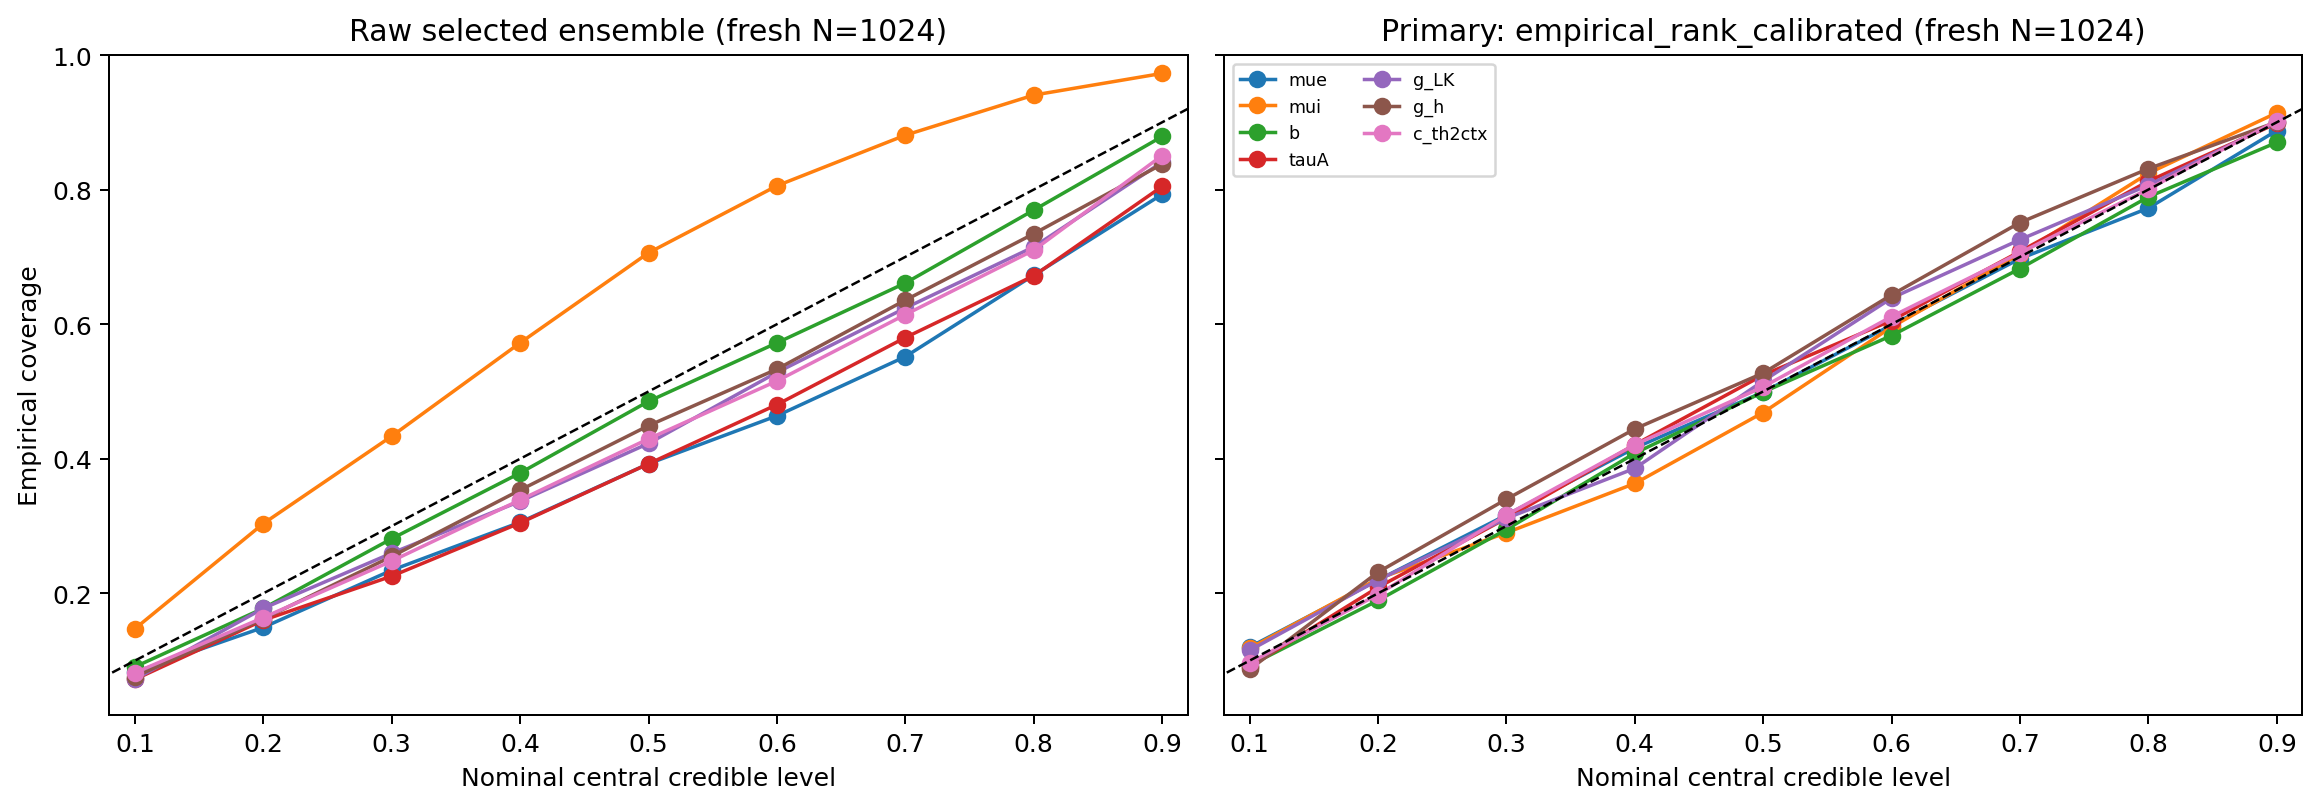

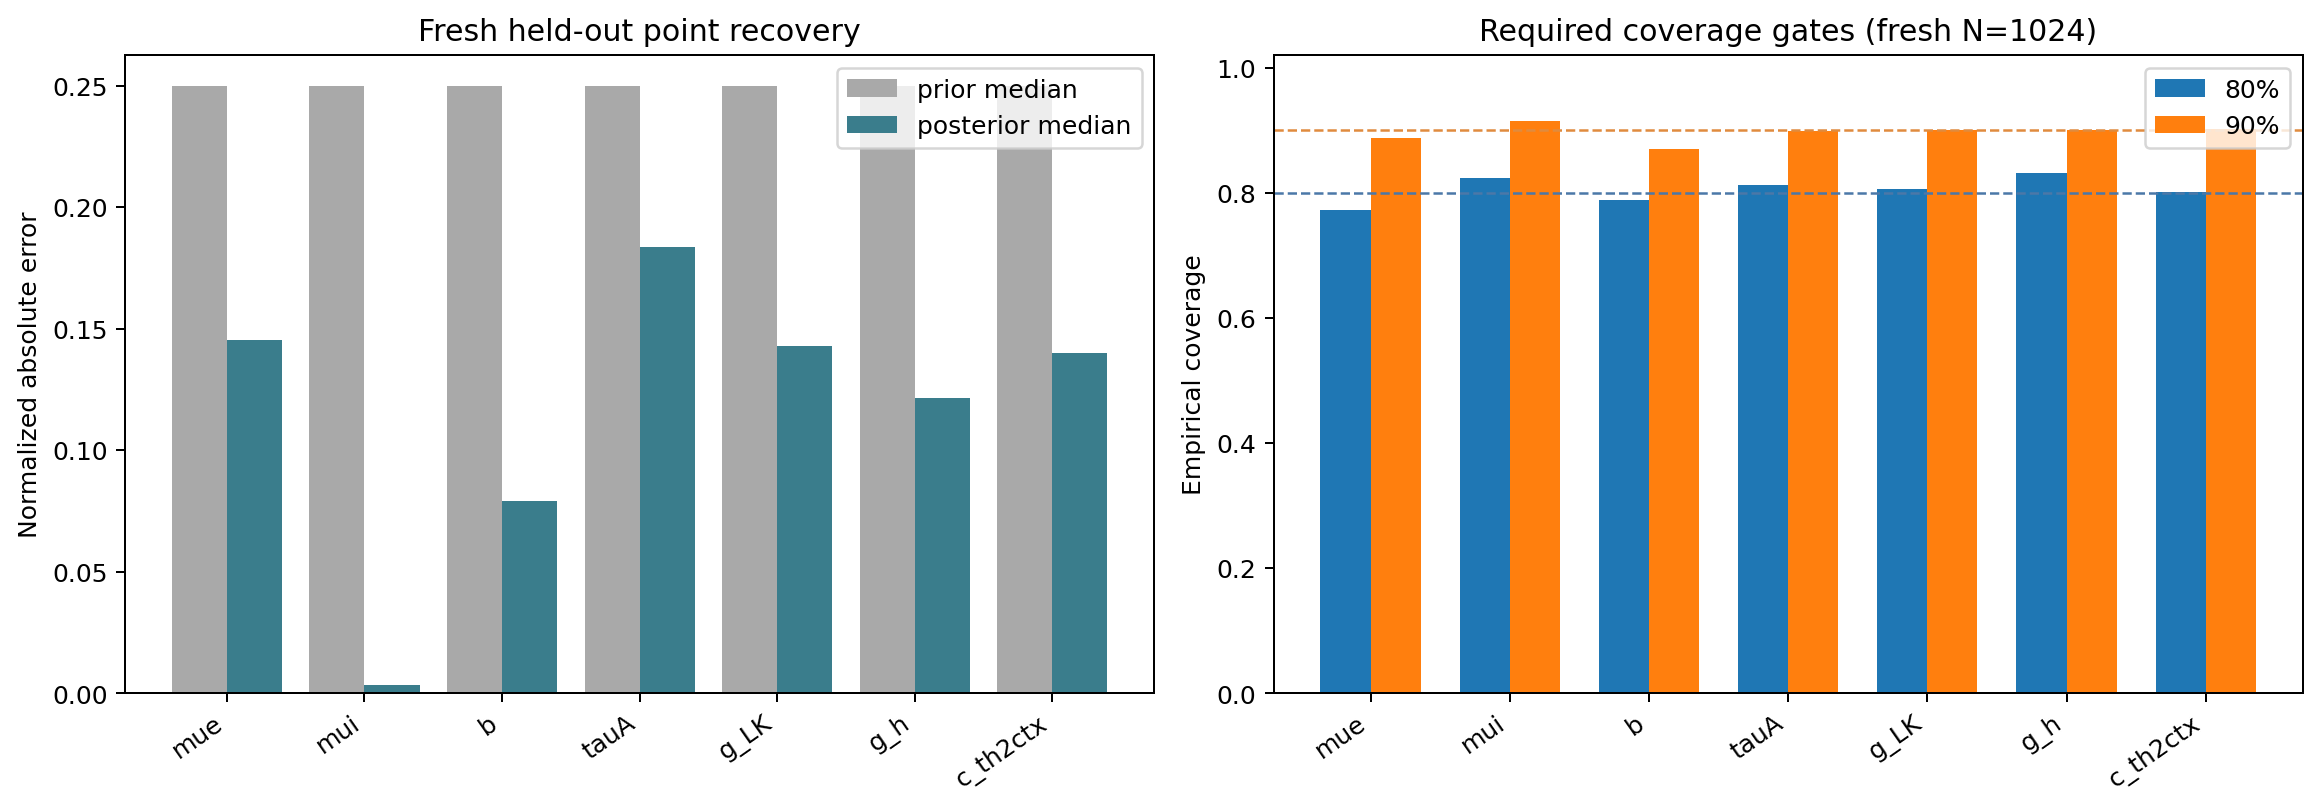

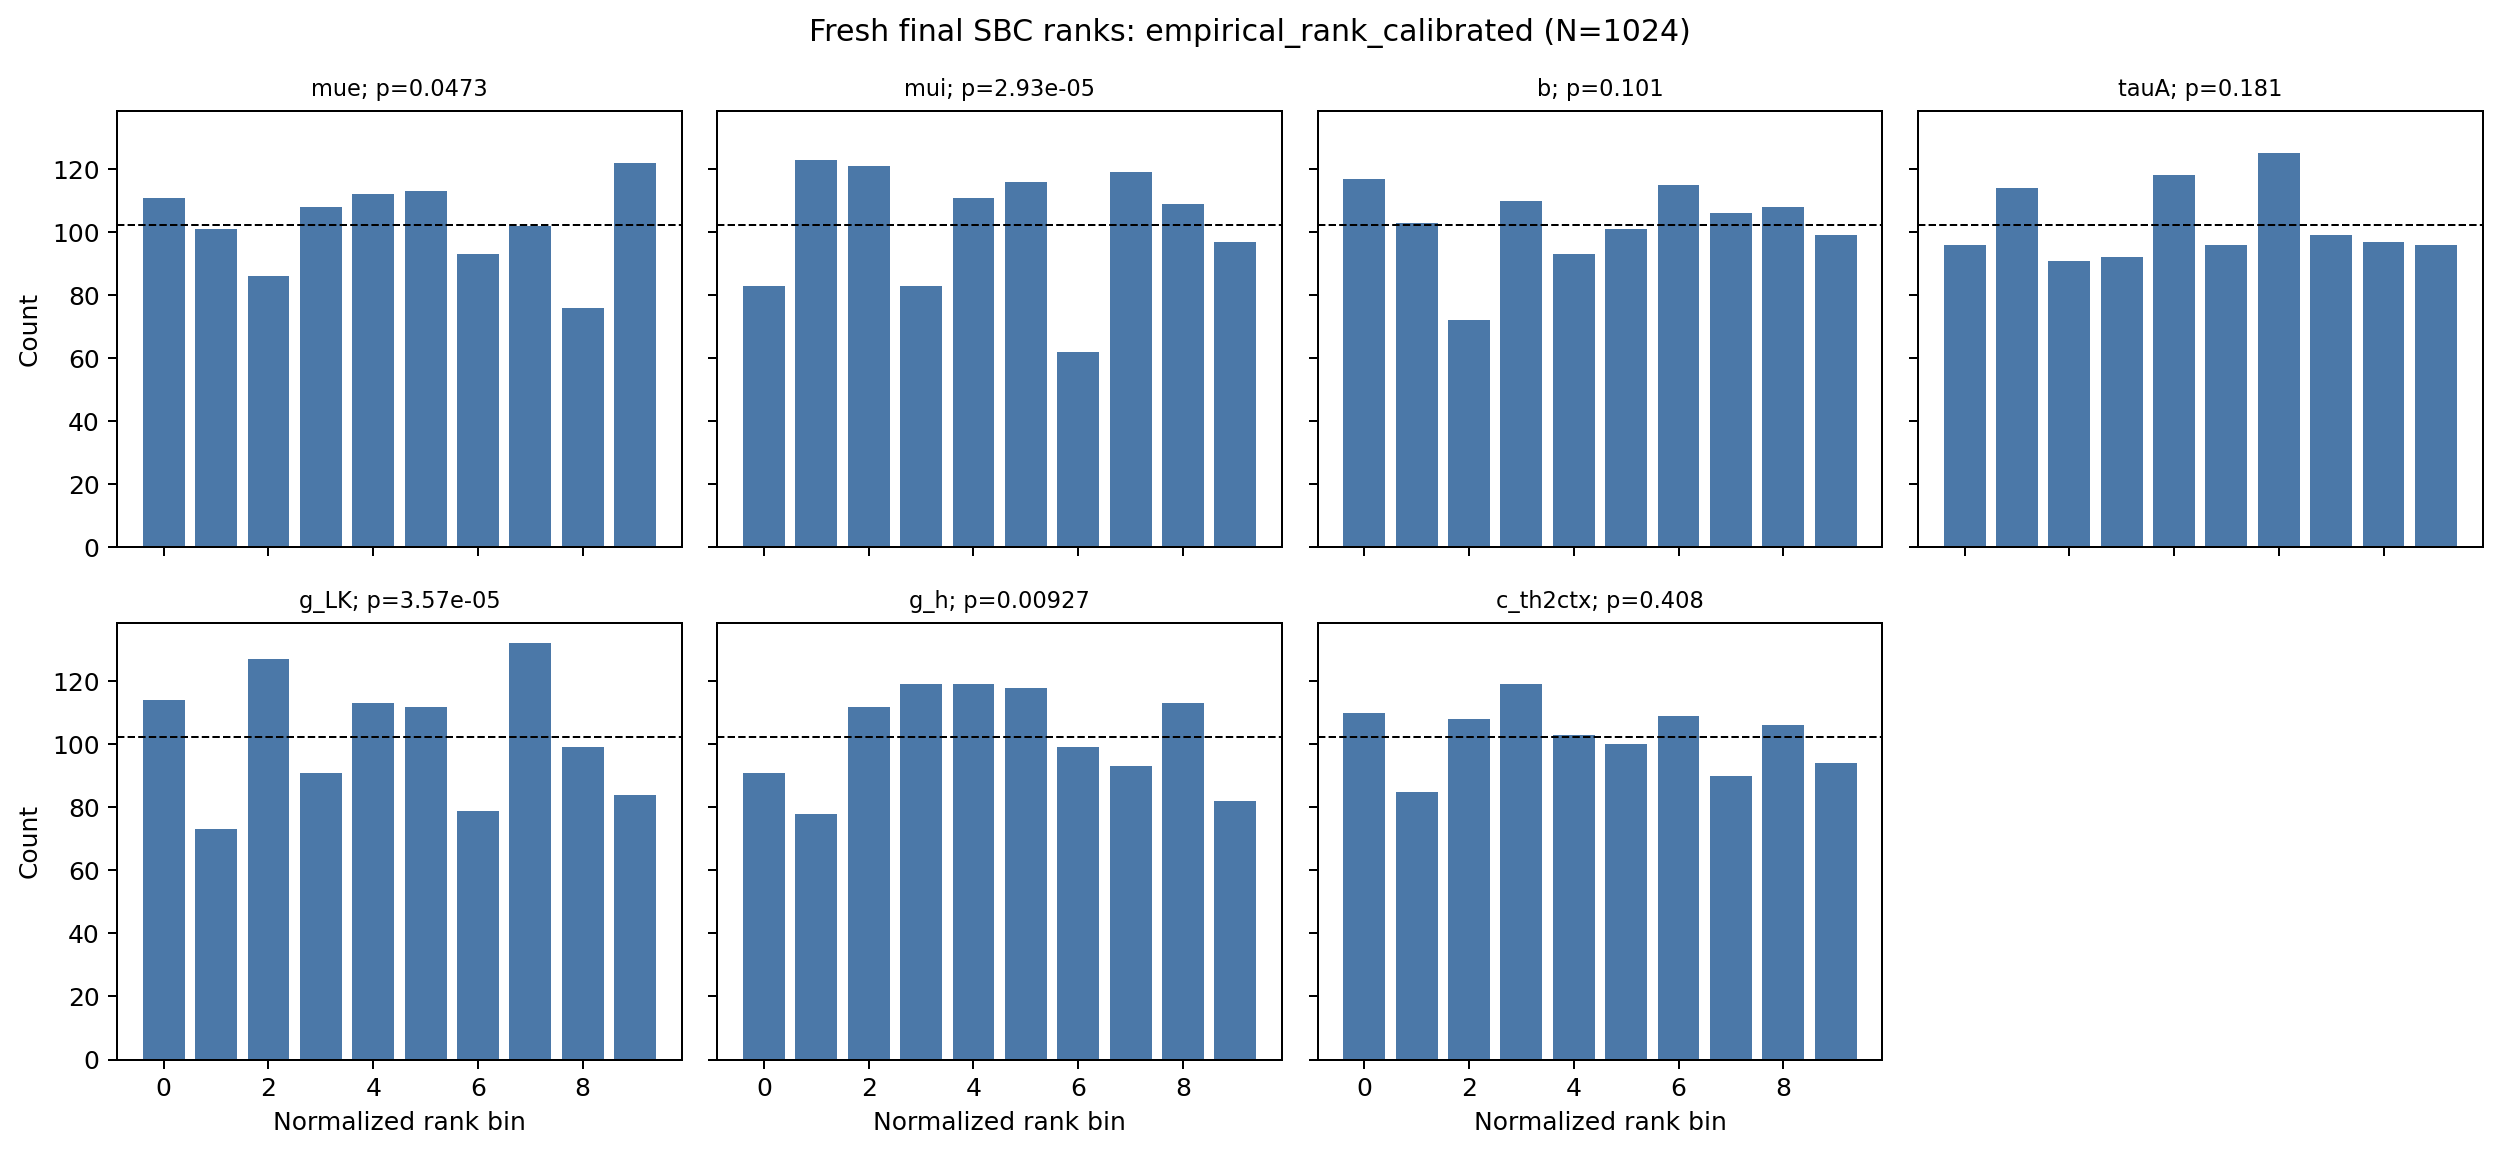

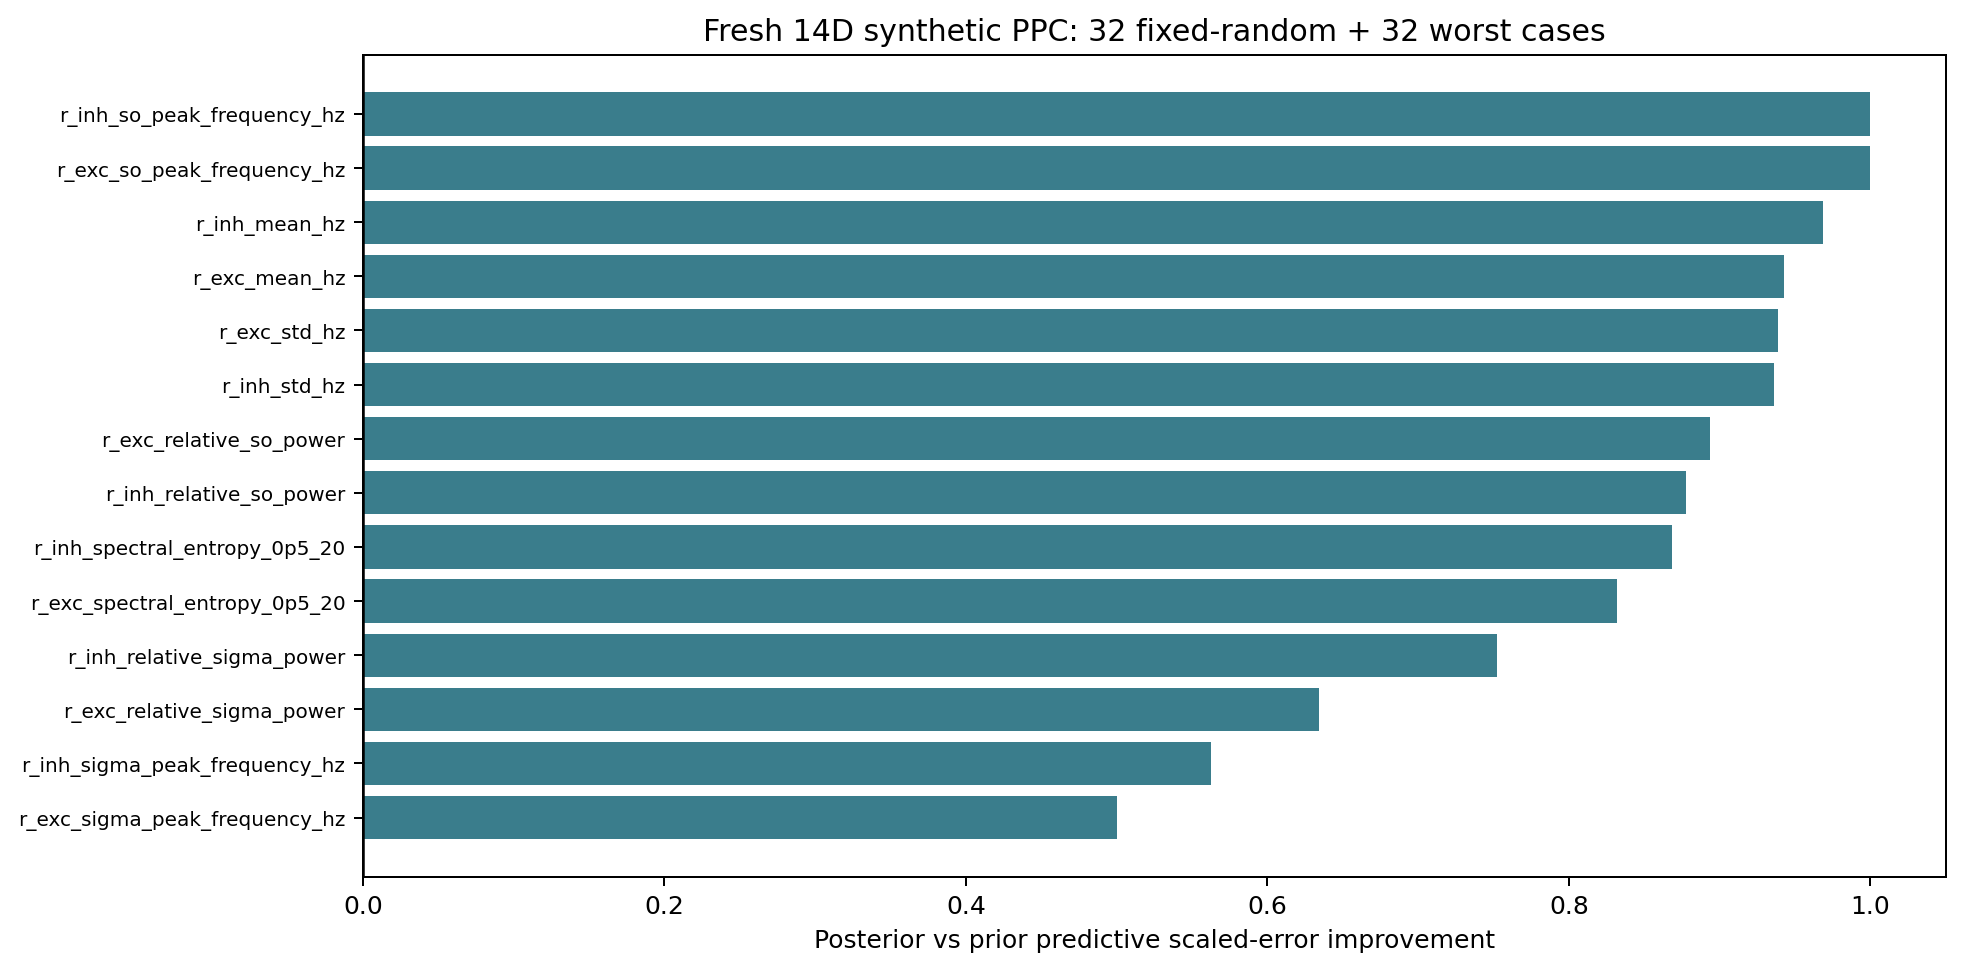

In [4]:
from sleep_sbi.route3_7d_rescue_reporting import plot_final_validation
figures = plot_final_validation()
for png, svg in figures:
    display(Image(filename=str(png)))


## Synthetic 14D posterior predictive check


In [5]:
ppc = json.loads((FINAL_ROOT / "ppc" / "ppc_summary.json").read_text())
display(pd.Series(ppc, name="value").to_frame())
assert ppc["posterior_predictive_attempted"] == 1024
assert ppc["prior_predictive_attempted"] == 1024


,value
cases,64
random_cases,32
worst_cases,32
posterior_draws_per_case,16
posterior_predictive_attempted,1024
posterior_predictive_failed,0
prior_predictive_attempted,1024
prior_predictive_failed,0
features_posterior_better,14
overall_posterior_scaled_error,0.070505


## Frozen decision

The verdict below is generated by the original numerical logic. If the primary
method is calibrated, the preregistration caps scientific status below Formal GO.
The result never unlocks real Fpz-Cz inference.


In [6]:
display(Markdown(f"# {decision['verdict']}"))
display(pd.Series({
    "applies_to": decision["applies_to"],
    "fresh_cases": decision["fresh_final_cases"],
    "coverage_pass_7": decision["parameters_passing_all_80_90_coverage_requirements"],
    "coverage_plus_contraction_7": decision["parameters_passing_coverage_plus_contraction"],
    "blockers": ", ".join(decision["blockers"]) or "none",
}).to_frame("value"))


# NO-GO

,value
applies_to,empirical_rank_calibrated
fresh_cases,1024
coverage_pass_7,4
coverage_plus_contraction_7,4
blockers,"coverage_compatible_gate, contraction_with_cov..."
